In [1]:
# ─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from statsmodels.stats.outliers_influence import variance_inflation_factor


# ─────────────────────────────────────────────
# 2. DATA LOADING & INSPECTION
# ─────────────────────────────────────────────
df = pd.read_csv('cancer data.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nClass distribution:")
print(df['Diagnosis'].value_counts())


Shape: (569, 32)

First 5 rows:
         ID  radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    842302    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    842517    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2  84300903    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3  84348301    11.42     20.38       77.58   386.1      0.14250       0.28390   
4  84358402    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  ...  texture3  perimeter3   area3  \
0      0.3001          0.14710     0.2419  ...     17.33      184.60  2019.0   
1      0.0869          0.07017     0.1812  ...     23.41      158.80  1956.0   
2      0.1974          0.12790     0.2069  ...     25.53      152.50  1709.0   
3      0.2414          0.10520     0.2597  ...     26.50       98.87   567.7   
4      0.1980          0.10430     0.1809  ...     16.67      152.20  1575.0   




Encoded classes: {'B': np.int64(0), 'M': np.int64(1)}


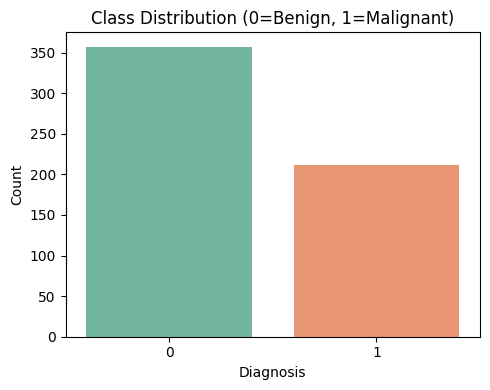

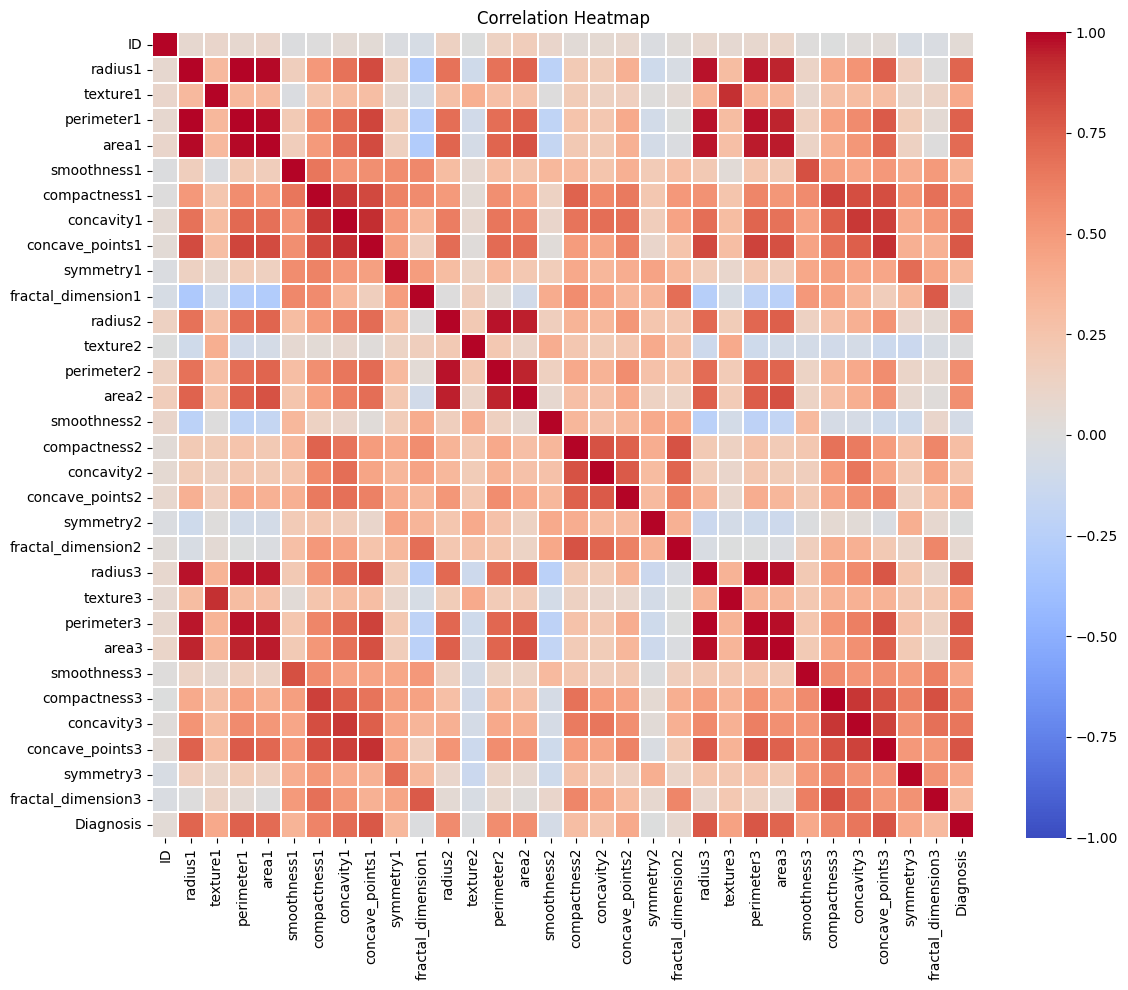

In [2]:
# ─────────────────────────────────────────────
# 3. LABEL ENCODING
# ─────────────────────────────────────────────
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])   # M=1, B=0
print("\nEncoded classes:", dict(zip(le.classes_, le.transform(le.classes_))))


# ─────────────────────────────────────────────
# 4. EDA
# ─────────────────────────────────────────────

# 4a. Class distribution
plt.figure(figsize=(5, 4))
sns.countplot(x='Diagnosis', data=df, palette='Set2')
plt.title('Class Distribution (0=Benign, 1=Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 4b. Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), vmin=-1, vmax=1, cmap='coolwarm', linewidths=0.3)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [3]:
# ─────────────────────────────────────────────
# 5. FEATURE SELECTION — VIF
# Drop ID-like first column explicitly if present
# ─────────────────────────────────────────────
# Exclude target; also drop any ID column by name if present
id_cols = [c for c in df.columns if c.lower() in ('id', 'patient_id', 'unnamed: 0')]
feature_df = df.drop(columns=['Diagnosis'] + id_cols)

def calculate_vif(data: pd.DataFrame) -> pd.DataFrame:
    vif = pd.DataFrame()
    vif['Feature'] = data.columns
    vif['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif.sort_values('VIF', ascending=False).reset_index(drop=True)

VIF_THRESHOLD = 10
removed = []

while True:
    vif_df = calculate_vif(feature_df)
    worst = vif_df.iloc[0]
    if worst['VIF'] > VIF_THRESHOLD:
        print(f"Removing '{worst['Feature']}' — VIF: {worst['VIF']:.2f}")
        removed.append(worst['Feature'])
        feature_df = feature_df.drop(columns=[worst['Feature']])
    else:
        break

print(f"\nFeatures removed by VIF: {removed}")
print(f"Remaining features ({len(feature_df.columns)}): {list(feature_df.columns)}")

Removing 'radius1' — VIF: 63306.17
Removing 'radius3' — VIF: 7573.94
Removing 'perimeter1' — VIF: 3901.90
Removing 'perimeter3' — VIF: 668.39
Removing 'fractal_dimension1' — VIF: 508.09
Removing 'smoothness3' — VIF: 368.05
Removing 'texture3' — VIF: 309.54
Removing 'fractal_dimension3' — VIF: 184.68
Removing 'symmetry3' — VIF: 167.31
Removing 'concavity1' — VIF: 142.30
Removing 'radius2' — VIF: 104.99
Removing 'concave_points3' — VIF: 100.95
Removing 'smoothness1' — VIF: 87.00
Removing 'compactness1' — VIF: 74.72
Removing 'area1' — VIF: 67.47
Removing 'compactness3' — VIF: 49.02
Removing 'perimeter2' — VIF: 43.73
Removing 'symmetry1' — VIF: 36.08
Removing 'texture1' — VIF: 23.71
Removing 'concave_points2' — VIF: 18.16
Removing 'compactness2' — VIF: 15.73
Removing 'area3' — VIF: 13.98
Removing 'concave_points1' — VIF: 11.18

Features removed by VIF: ['radius1', 'radius3', 'perimeter1', 'perimeter3', 'fractal_dimension1', 'smoothness3', 'texture3', 'fractal_dimension3', 'symmetry3', 'con

In [4]:
# ─────────────────────────────────────────────
# 6. TRAIN / TEST SPLIT  (before any fitting)
# ─────────────────────────────────────────────
X = feature_df
y = df['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


# ─────────────────────────────────────────────
# 7. RFE — Feature selection on TRAIN only, then applied to both
# ─────────────────────────────────────────────
rfe_estimator = DecisionTreeClassifier(max_depth=5, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=7)
rfe.fit(X_train, y_train)

selected_features = X_train.columns[rfe.support_].tolist()
print(f"\nRFE selected features: {selected_features}")

ranking_df = pd.DataFrame({'Feature': X_train.columns, 'Rank': rfe.ranking_})
print(ranking_df.sort_values('Rank').to_string(index=False))

# Apply selection
X_train_rfe = X_train[selected_features]
X_test_rfe  = X_test[selected_features]


Train size: 398 | Test size: 171

RFE selected features: ['texture2', 'area2', 'smoothness2', 'concavity2', 'symmetry2', 'fractal_dimension2', 'concavity3']
           Feature  Rank
          texture2     1
             area2     1
       smoothness2     1
        concavity2     1
         symmetry2     1
fractal_dimension2     1
        concavity3     1


In [5]:
# ─────────────────────────────────────────────
# 8. PIPELINES
# ─────────────────────────────────────────────
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

dt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=42))
])


# ─────────────────────────────────────────────
# 9. CROSS-VALIDATION (on full VIF-filtered features)
# ─────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipe in [('Logistic Regression', lr_pipeline), ('Decision Tree', dt_pipeline)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    print(f"{name} — CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression — CV ROC-AUC: 0.9801 ± 0.0148
Decision Tree — CV ROC-AUC: 0.8938 ± 0.0373


In [6]:
# ─────────────────────────────────────────────
# 10. HYPERPARAMETER TUNING — Decision Tree
# ─────────────────────────────────────────────
param_grid = {
    'clf__max_depth':        [3, 5, 7, 10, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf':  [1, 2, 4]
}

grid_search = GridSearchCV(
    dt_pipeline, param_grid,
    cv=cv, scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print(f"\nBest DT params: {grid_search.best_params_}")
print(f"Best DT CV ROC-AUC: {grid_search.best_score_:.4f}")
best_dt = grid_search.best_estimator_


Best DT params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 2}
Best DT CV ROC-AUC: 0.9238


In [7]:
# ─────────────────────────────────────────────
# 11. TRAIN FINAL MODELS & EVALUATE
# ─────────────────────────────────────────────
models = {
    'Logistic Regression': lr_pipeline,
    'Decision Tree (tuned)': best_dt
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred      = model.predict(X_test)
    y_prob      = model.predict_proba(X_test)[:, 1]
    roc_auc     = roc_auc_score(y_test, y_prob)
    results[name] = {'y_pred': y_pred, 'y_prob': y_prob, 'roc_auc': roc_auc}

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))
    print(f"  ROC-AUC: {roc_auc:.4f}")


  Logistic Regression
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97       107
   Malignant       0.98      0.91      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

  ROC-AUC: 0.9972

  Decision Tree (tuned)
              precision    recall  f1-score   support

      Benign       0.94      0.95      0.95       107
   Malignant       0.92      0.91      0.91        64

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171

  ROC-AUC: 0.9533


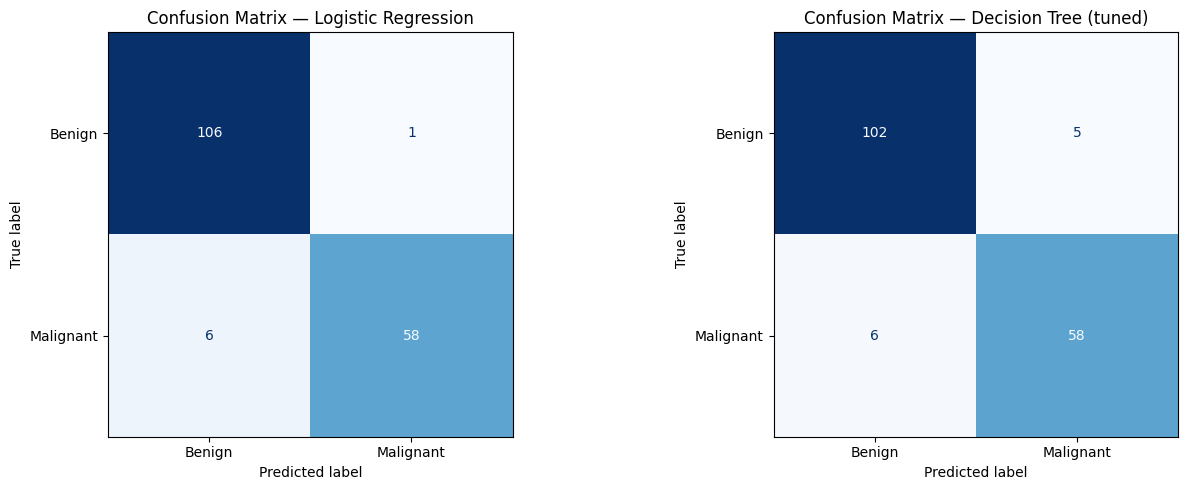

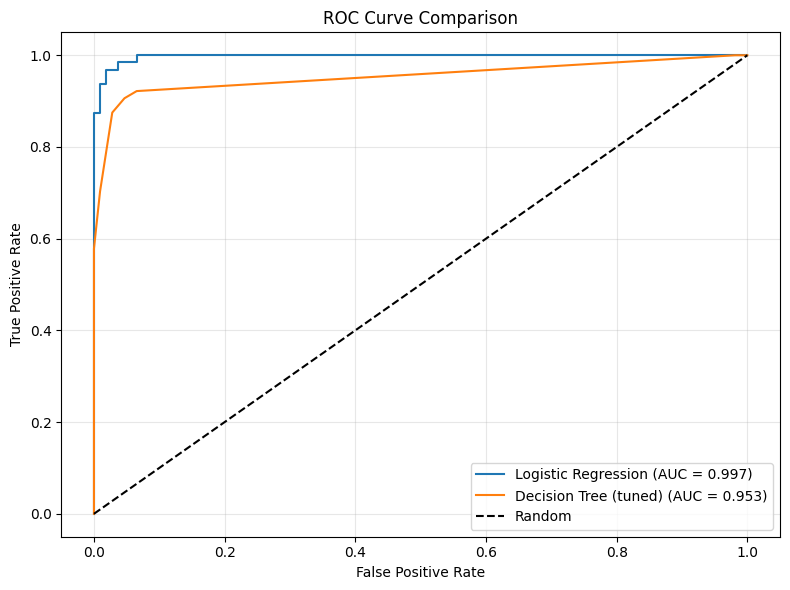

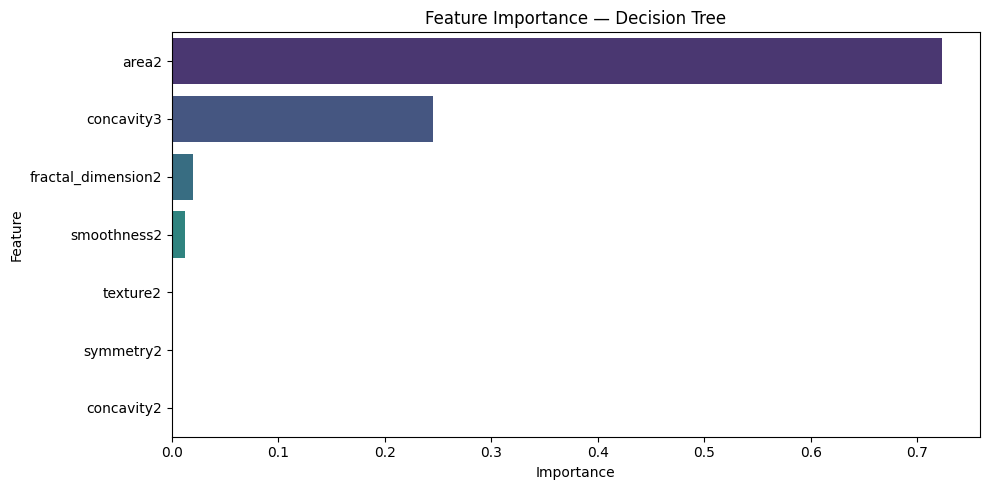

In [8]:
# ─────────────────────────────────────────────
# 12. VISUALIZATIONS
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Benign', 'Malignant'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}')

plt.tight_layout()
plt.show()


# ROC curves (both models on same plot)
plt.figure(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Feature importance from tuned Decision Tree
dt_clf = best_dt.named_steps['clf']
importance_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': dt_clf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Decision Tree')
plt.tight_layout()
plt.show()

In [9]:
# ─────────────────────────────────────────────
# 13. DECISION TREE on RFE FEATURES (comparison)
# ─────────────────────────────────────────────
dt_rfe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(**{
        k.replace('clf__', ''): v
        for k, v in grid_search.best_params_.items()
    }, random_state=42))
])
dt_rfe.fit(X_train_rfe, y_train)
y_pred_rfe = dt_rfe.predict(X_test_rfe)
y_prob_rfe = dt_rfe.predict_proba(X_test_rfe)[:, 1]
roc_rfe = roc_auc_score(y_test, y_prob_rfe)

print(f"\nDT on RFE features ROC-AUC: {roc_rfe:.4f}")
print(f"DT on all VIF features ROC-AUC: {results['Decision Tree (tuned)']['roc_auc']:.4f}")


# ─────────────────────────────────────────────
# 14. SAVE BEST MODEL
# ─────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best_model = models[best_name]

joblib.dump(best_model, 'breast_cancer_best_model.pkl')
print(f"\nBest model: '{best_name}' (ROC-AUC: {results[best_name]['roc_auc']:.4f})")
print("Model saved to: breast_cancer_best_model.pkl")

# Quick load + predict sanity check
loaded_model = joblib.load('breast_cancer_best_model.pkl')
sample = X_test.iloc[:3]
print("\nSample predictions:", loaded_model.predict(sample))
print("Actual:            ", y_test.iloc[:3].values)


DT on RFE features ROC-AUC: 0.9533
DT on all VIF features ROC-AUC: 0.9533

Best model: 'Logistic Regression' (ROC-AUC: 0.9972)
Model saved to: breast_cancer_best_model.pkl

Sample predictions: [0 0 0]
Actual:             [0 0 0]
